# Gene Report Module  
> This module focuses on the **GeneReports** class, which extends the capabilities of the AnnDataIso and TranscriptPlots classes to provide comprehensive gene-level analysis and visualization tools. It is specifically designed to handle gene expression data, offering specialized methods to efficiently manage and analyze data from various single-cell RNA sequencing protocols, facilitating seamless integration and manipulation within the Allos framework.  

As the field of single-cell RNA sequencing continues to advance, the Gene Report Module offers a robust and adaptable structure that can be extended to meet specific research needs. While it serves as a comprehensive foundation, we encourage the community to contribute by enhancing its capabilities and developing additional functionalities tailored to unique analytical requirements. This collaborative effort aims to build a dynamic ecosystem where users can leverage shared innovations and protocol-specific enhancements.  

The primary objective is to empower researchers to work effortlessly with gene-level single-cell RNA sequencing data in Allos, ensuring compatibility and efficiency across diverse datasets while benefiting from community-driven advancements.


In [1]:
#| hide
from nbdev.showdoc import *

In [2]:
#| default_exp gene_report

In [1]:
#| export
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import csr_matrix
import anndata as ad
import seaborn as sns
import requests
import sys
import patchworklib as pw
import urllib
import os
import gzip
import shutil
import matplotlib.pyplot as plt
from scipy.special import gammaln
from scipy.optimize import minimize
from itertools import combinations
from typing import List, Tuple, Dict, Union, Optional
from functools import lru_cache
import pyranges as pr
from pyfaidx import Fasta
import logging
import base64
import io

from scipy.sparse import coo_matrix

from allos.anndata_iso import AnnDataIso
from allos.transcript_plots import TranscriptPlots
from allos.color_palette import ghibli, synthwave
import matplotlib.patches as mpatches
from anndata import AnnData

<Figure size 100x100 with 0 Axes>

In [ ]:
   

       
    # def write_gene_report(self, gene_id, filename='report.html'):
    #     with open(filename, 'w') as f:
    #         f.write("<html><head><title>Gene report</title></head><body>")
    #         f.write("<h1>Gene report</h1>")
    #         f.write("<h2>Isoforms summary</h2>")
    #         f.write('<img src="data:image/jpeg;base64,{0}" style="width: 100%">'.format(self._plot_isoforms_summary_to_jpeg_base64()))
    #         f.write("<p>Below is a summary of the isoforms</p>")
    #         f.write("<h2>Transcripts</h2>")
    #         my_stringIObytes = io.BytesIO()
    #         ax1 = pw.Brick(figsize=(4, 4))
    #         self.plot_transcript_exspression_dotplot(gene_id, ax=ax1)
    #         ax1.savefig(my_stringIObytes, format='jpg')
    #         my_stringIObytes.seek(0)
    #         figure_b64 = base64.b64encode(my_stringIObytes.read()).decode()
    #         f.write('<img src="data:image/jpeg;base64,{0}" style="width: 100%">'.format(figure_b64))
    #         f.write("<h2>Transcripts</h2>")
    #         f.write("<ul>")
    #         for transcript_id in self.var[self.var['geneId']==gene_id]["transcriptId"].unique():
    #             f.write("<li>%s" % transcript_id)
    #             f.write("<img src='data:image/jpeg;base64,{0}' style='width: 50%'>".format(self.plot_transcripts(transcripts=[transcript_id])))
    #             f.write("</li>")
    #         f.write("</ul>")
    #         f.write("</body></html>")
    # def generate_quarto_report(self, gene_id, output_file="gene_report.html"):
    #     """
    #     Generates a Quarto report by passing the gene_id dynamically.
    #     """
    #     # Read Quarto template
    #     with open("report_template.qmd", "r") as template_file:
    #         template_content = template_file.read()

    #     # Fill template with gene_id
    #     report_content = jinja2.Template(template_content).render(gene_id=gene_id)

    #     # Save updated Quarto file
    #     with open("generated_gene_report.qmd", "w") as output_file:
    #         output_file.write(report_content)

    #     # Render the report to HTML (or PDF)
    #     subprocess.run(["quarto", "render", "generated_gene_report.qmd", "--to", "html"])

    #     print(f"✅ Quarto report generated successfully: gene_report.html")

    # More detailed functions omitted for brevity.

In [ ]:
#| export
def plot_switching_results(self, gene_label_column='gene_id'):
        """
        Visualizes isoform switching results with scatter plots for each comparison.

        Parameters:
        - df : pd.DataFrame
            A dataframe with results containing at least the following columns:
            ['group_1', 'group_2', 'cell_type', 'delta_psi', 'adj_pval', 'n_cells_group1', 'n_cells_group2', 'total_count']
        - gene_label_column : str
            Optional column name to use for labeling significant dots. Default is 'gene_id'.
        """
        # Check necessary columns
        df = pd.DataFrame(np.transpose(self.X), columns=self.obs[gene_label_column])
        required_columns = {'group_1', 'group_2', 'cell_type', 'delta_psi', 'adj_pval', 'n_cells_group1', 'n_cells_group2', 'total_count'}
        if not required_columns.issubset(df.columns):
            missing = required_columns - set(df.columns)
            raise ValueError(f"Missing required columns in input dataframe: {missing}")

        # Create 'comparison' column
        df['comparison'] = df['group_1'] + ' vs ' + df['group_2'] + ' in ' + df['cell_type']
        unique_comparisons = df['comparison'].unique()
        n_comparisons = len(unique_comparisons)

        ncols = int(np.ceil(np.sqrt(n_comparisons)))
        nrows = int(np.ceil(n_comparisons / ncols))

        pval_threshold = 0.05
        delta_psi_threshold = 0.1
        log_pval_thresh = -np.log10(pval_threshold)

        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)

        for idx, comp in enumerate(unique_comparisons):
            row, col = divmod(idx, ncols)
            ax = axes[row][col]

            sub_df = df[df['comparison'] == comp].copy()
            sub_df['-log10_adj_pval'] = -np.log10(sub_df['adj_pval'])

            # Scale dot size
            size = (sub_df['total_count'] - sub_df['total_count'].min()) / (
                sub_df['total_count'].max() - sub_df['total_count'].min() + 1e-9  # avoid division by 0
            ) * 200 + 10

            # Dot color: combined cell count
            color = sub_df['n_cells_group1'] + sub_df['n_cells_group2']

            sc = ax.scatter(
                sub_df['delta_psi'],
                sub_df['-log10_adj_pval'],
                s=size,
                c=color,
                cmap='viridis',
                alpha=0.7,
                edgecolors='k',
                linewidths=0.2
            )

            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label('Expressing cells (group1 + group2)', fontsize=9)

            # Add threshold lines
            ax.axhline(log_pval_thresh, color='red', linestyle='--', linewidth=0.8)
            ax.axvline(-delta_psi_threshold, color='blue', linestyle='--', linewidth=0.8)
            ax.axvline(delta_psi_threshold, color='blue', linestyle='--', linewidth=0.8)

            # Add text labels if gene_label_column exists
            if gene_label_column in sub_df.columns:
                sig_hits = sub_df[
                    (sub_df['adj_pval'] < pval_threshold) &
                    (abs(sub_df['delta_psi']) > delta_psi_threshold)
                ]
                for _, row_data in sig_hits.iterrows():
                    ax.text(
                        row_data['delta_psi'],
                        row_data['-log10_adj_pval'],
                        str(row_data[gene_label_column]),
                        fontsize=7,
                        ha='right' if row_data['delta_psi'] < 0 else 'left',
                        va='bottom'
                    )

            ax.set_title(comp)
            ax.set_xlabel('ΔPSI')
            ax.set_ylabel('-log10(adj p-value)')

        # Hide unused subplots
        for idx in range(n_comparisons, nrows * ncols):
            fig.delaxes(axes.flatten()[idx])

        plt.tight_layout()
        plt.show()

In [ ]:
#| export
def plot_combined_panel_on_condition(switch_data, dge_data=None, dge_short_data=None, gene_name=None, conditions_list=[], cell_types=[], ctrl_condition='ctrl'):
        has_switch_data = switch_data is not None
        has_dge_data = dge_data is not None and dge_short_data is not None
        legend_switch = []
        legend_dge = []
        dge_ax_id = -1 if not has_dge_data else 0
        switch_ax_id = -1 if not has_switch_data else (0 if not has_dge_data else 1)
        n_axs = 2 if has_switch_data and has_dge_data else (0 if not has_switch_data and not has_dge_data else 1)
        if gene_name is None:
            raise ValueError("No data available for plotting. Please check the input parameters.")
        switch_data = switch_data[switch_data['gene_id'] == gene_name]
        if n_axs == 0:
            raise ValueError("No data available for plotting. Please check the input parameters.")
        index = 0
        if cell_types == []:
            cell_types = list(set(list(switch_data['group_1'].unique())))
        if conditions_list == []:
            conditions_list = cell_types
        # Prepare switch data
        if has_switch_data:
            switch_ids = set(switch_data['transcript_id'].unique())
            switch_colors = dict()
        # Create plot
        fig, axs = plt.subplots(len(conditions_list), n_axs, figsize=(14, len(conditions_list)), gridspec_kw={'width_ratios': [1, 2] if n_axs == 2 else [1]}, constrained_layout=True)
        min_x = -1.2
        max_x = 0.1

        while index < len(conditions_list):
            ax_switch = None
            ax_dge = None
            conditions = conditions_list[index]
            # Compute DGE data
            if has_dge_data:
                if n_axs == 2:
                    ax_dge = axs[index][dge_ax_id]
                else:
                    ax_dge = axs[index]
                # Prepare stacked bar data
                switch_ids = set(switch_data['transcript_id'].unique())

                # Plot log2FC barplot
                # log2fc_df = log2fc_df[log2fc_df['cell_type'].isin(conditions)]
                dge_long = dge_data.copy()
                dge_long = dge_long[dge_long['comparison'].str.startswith('condition')]
                dge_long['source'] = 'long_read'
                dge_long['comparison'] = dge_long['comparison'].str.replace(ctrl_condition, 'ctrl')
                for condition in conditions:
                    dge_long = dge_long[dge_long['comparison'].str.contains(condition)]

                # Prepare short-read data
                dge_short = dge_short_data.copy()
                dge_short['source'] = 'short_read'
                dge_short['condition'] = dge_short['condition'].str.replace(ctrl_condition, 'ctrl')
                dge_short.rename(columns={'condition': 'comparison'}, inplace=True)
                for condition in conditions:
                    dge_short = dge_short[dge_short['comparison'].str.contains(condition)]
                # Combine and format for plotting
                combined_df = pd.concat([
                    dge_long[['comparison', 'log2FoldChange', 'source']],
                    dge_short[['comparison', 'log2FoldChange', 'source']]
                ])

                # Create group labels
                log2fc_df = combined_df.copy()
                log2fc_df['cell_type'] = log2fc_df['comparison'].str.extract(r'_(' + '|'.join(cell_types) + r')')[0]
                log2fc_df['group'] = log2fc_df['comparison']
                sns.barplot(data=log2fc_df, x='log2FoldChange', y='group', hue='source', ax=ax_dge, palette=synthwave)
                if index == 0:
                    ax_dge.set_title("Log2 Fold Change\n(Short vs Long Reads)")
                else:
                    ax_dge.set_title("")
                ax_dge.axvline(0, color='gray', linestyle='--', linewidth=0.8)
                if index == len(conditions_list) - 1:
                    ax_dge.set_xlabel("log2FC")
                else:
                    ax_dge.set_xticks([])
                    ax_dge.set_xlabel("")
                ax_dge.set_ylabel("")
                ax_dge.set_yticks([])
                ax_dge.set_xlim(min_x, max_x)
                ax_dge.legend_.remove() 
                legend_dge = [mpatches.Patch(color=color, label=gtype) for gtype, color in zip(['Long reads', 'Short reads'], synthwave)]
            # Compute Switch data
            if has_switch_data:
                if n_axs == 2:
                    ax_switch = axs[index][switch_ax_id]
                else:
                    ax_switch = axs[index]
                # Prepare long-read data (filter for conditions only)


                combined_data = []
                for cell_type in cell_types:
                    if cell_type != conditions:
                        continue
                    df = switch_data[switch_data['group_1'] == cell_type]
                    if df is None or df.empty:
                        continue
                    for _, row in df.iterrows():
                        for group_col, count_col in [('group_1', 'count_group1'), ('group_2', 'count_group2')]:
                            if row[group_col] != conditions:
                                continue
                            combined_data.append({
                                'cell_type': cell_type,
                                'transcript_id': row['transcript_id'],
                                'count': row[count_col]
                            })

                stacked_data = pd.DataFrame(combined_data)
                if stacked_data.empty:
                    print(f"No significant changes for condition `{cell_type}` under chosen threshold.")
                    index += 1
                    continue
                total_per_group = stacked_data.groupby('cell_type')['count'].transform('sum')
                stacked_data['percent'] = stacked_data['count'] / total_per_group * 100

                # Plot stacked barplot
                pivot_df = stacked_data.pivot_table(index='cell_type', columns='transcript_id', values='percent', fill_value=0)
                totals = stacked_data.groupby('cell_type')['count'].sum()
            
                pivot_df = pivot_df.loc[:, pivot_df.sum().sort_values(ascending=False).index]

                # Add labels and stars
                for i, (group_name, row) in enumerate(pivot_df.iterrows()):
                    cum_width = 0
                    for j, (transcript_id, percent) in enumerate(row.items()):
                        ghibli_colors = ghibli.copy()
                        while len(ghibli_colors) < len(switch_colors) + 1:
                            ghibli_colors += ghibli
                        if transcript_id not in switch_colors.keys():
                            switch_colors[transcript_id] = ghibli_colors[len(switch_colors)]
                        if percent > 5:
                            ax_switch.text(
                                cum_width + percent / 2,
                                i,
                                transcript_id,
                                va='center',
                                ha='center',
                                fontsize=7,
                                color='white' if percent > 20 else 'black'
                            )
                        if transcript_id in switch_ids and percent > 3:
                            ax_switch.text(
                                cum_width + percent - 1.5,
                                i,
                                '*',
                                va='center',
                                ha='right',
                                fontsize=12,
                                color='red',
                                weight='bold'
                            )
                        if percent > 3:
                            ax_switch.text(
                                cum_width + percent / 2,
                                i-0.4,
                                str(round(percent, 2)) + '%',
                                va='center',
                                ha='center',
                                fontsize=10,
                                color='black'
                            )
                        cum_width += percent
                pivot_df.plot(kind='barh', stacked=True, ax=ax_switch, color=switch_colors, edgecolor='white', linewidth=0.5)

                if index == len(conditions_list) - 1:
                    ax_switch.set_xlabel("Percentage of Transcript Counts")
                else:  
                    ax_switch.set_xlabel("")
                ax_switch.set_ylabel("")
                if index == 0:
                    ax_switch.set_title("Transcript Composition per Cell Type and Group")
                else:
                    ax_switch.set_title("")
                ax_switch.legend_.remove() 
                ax_switch.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
                legend_switch = [mpatches.Patch(color=color, label=tid) for tid, color in switch_colors.items()]
            # Combine legends at the bottom
            combined_legend = legend_switch + legend_dge
            fig.legend(handles=combined_legend, loc='lower center', bbox_to_anchor=(0.5, -0.175), ncol=5, title="Legend")

            plt.subplots_adjust(bottom=0.15)
            index += 1
        plt.show()
        return switch_colors

In [58]:
from allos.switch_search import SwitchSearch
from allos.preprocessing import filter_transcripts_by_abundance
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
adata = ad.read_h5ad('/data/analysis/data_mcandrew/Isoform_matrices/annotated_pacbio_pbmc_iso_level.h5ad')
filter_transcripts_by_abundance(adata,  threshold_pct= 2)
ss = SwitchSearch(adata, group_columns=['predicted_labels'], fast_mode=False)
pairwise = ss.find_switches_chi2(
            primary_col="predicted_labels",
            return_transcript_metrics=True)

In [59]:
# pairwise = pairwise[pairwise['adj_pval'] < 0.05]
pairwise_filtered = pairwise[pairwise['delta_psi'] >= 0.05]

Make use of Wilcoxon results and/or dirichlet results if the Switch search was run 

/tmp/ipykernel_2825501/716718748.py:182: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.15)
/tmp/ipykernel_2825501/716718748.py:182: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.15)
/tmp/ipykernel_2825501/716718748.py:182: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.15)
/tmp/ipykernel_2825501/716718748.py:182: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.15)
/tmp/ipykernel_2825501/716718748.py:182: UserWarning: This figure was using a layout engine that is incompatible with subplo

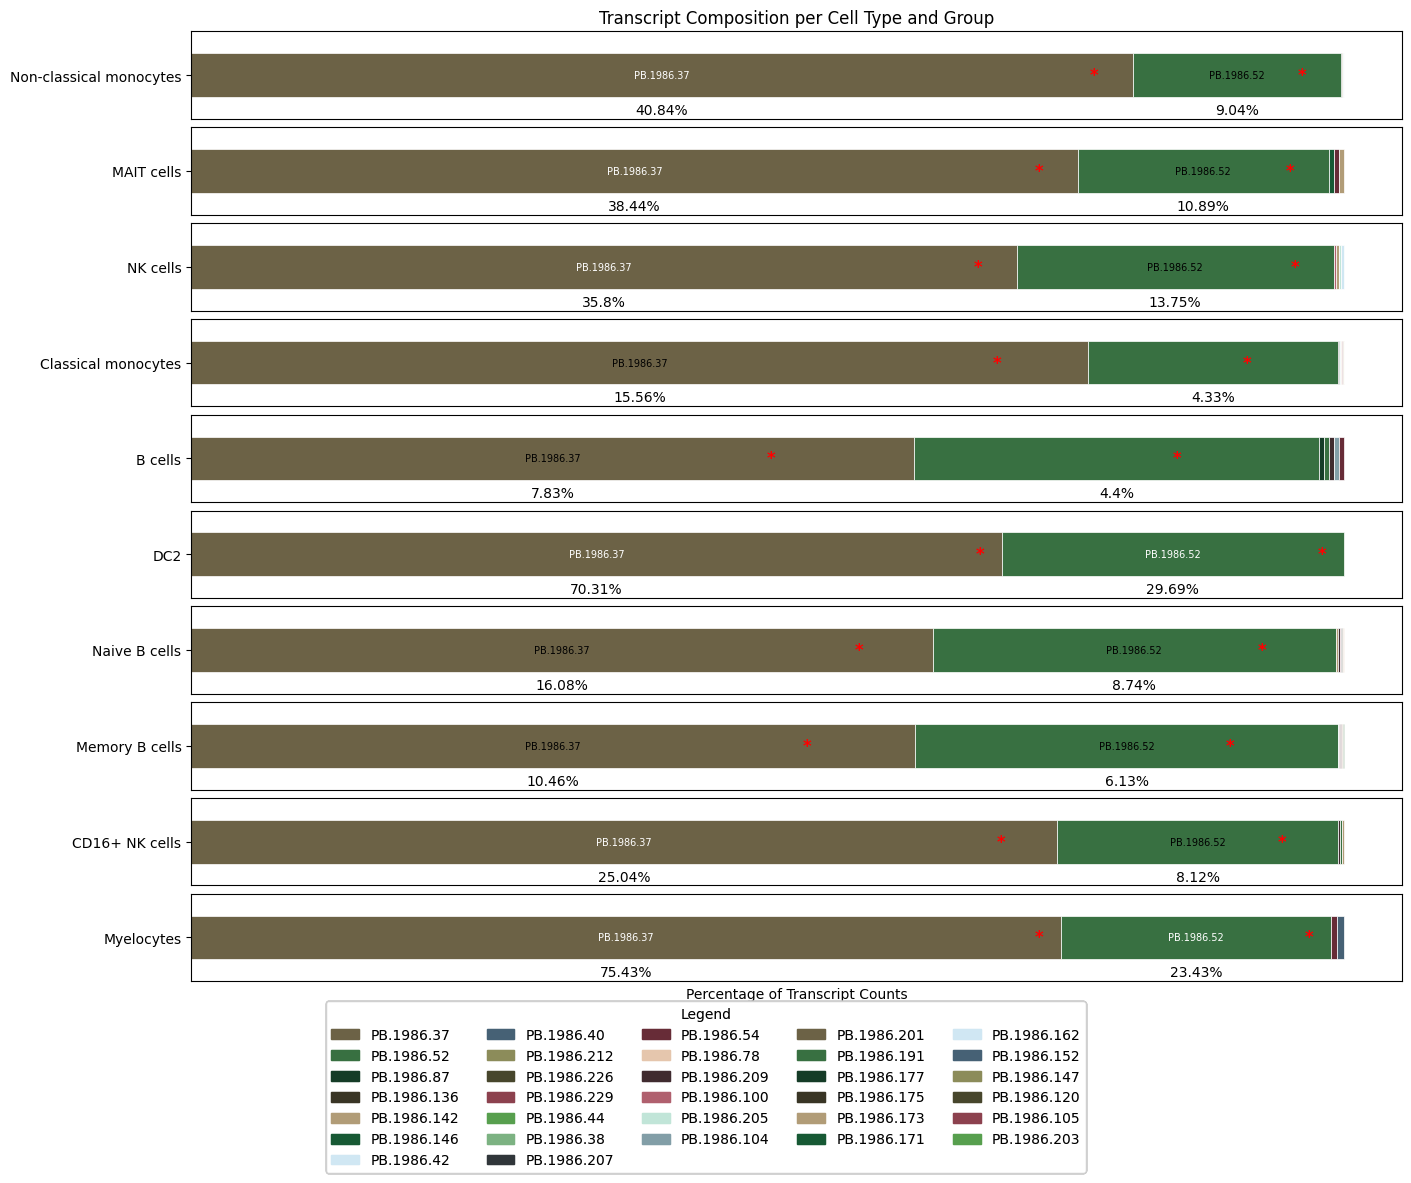

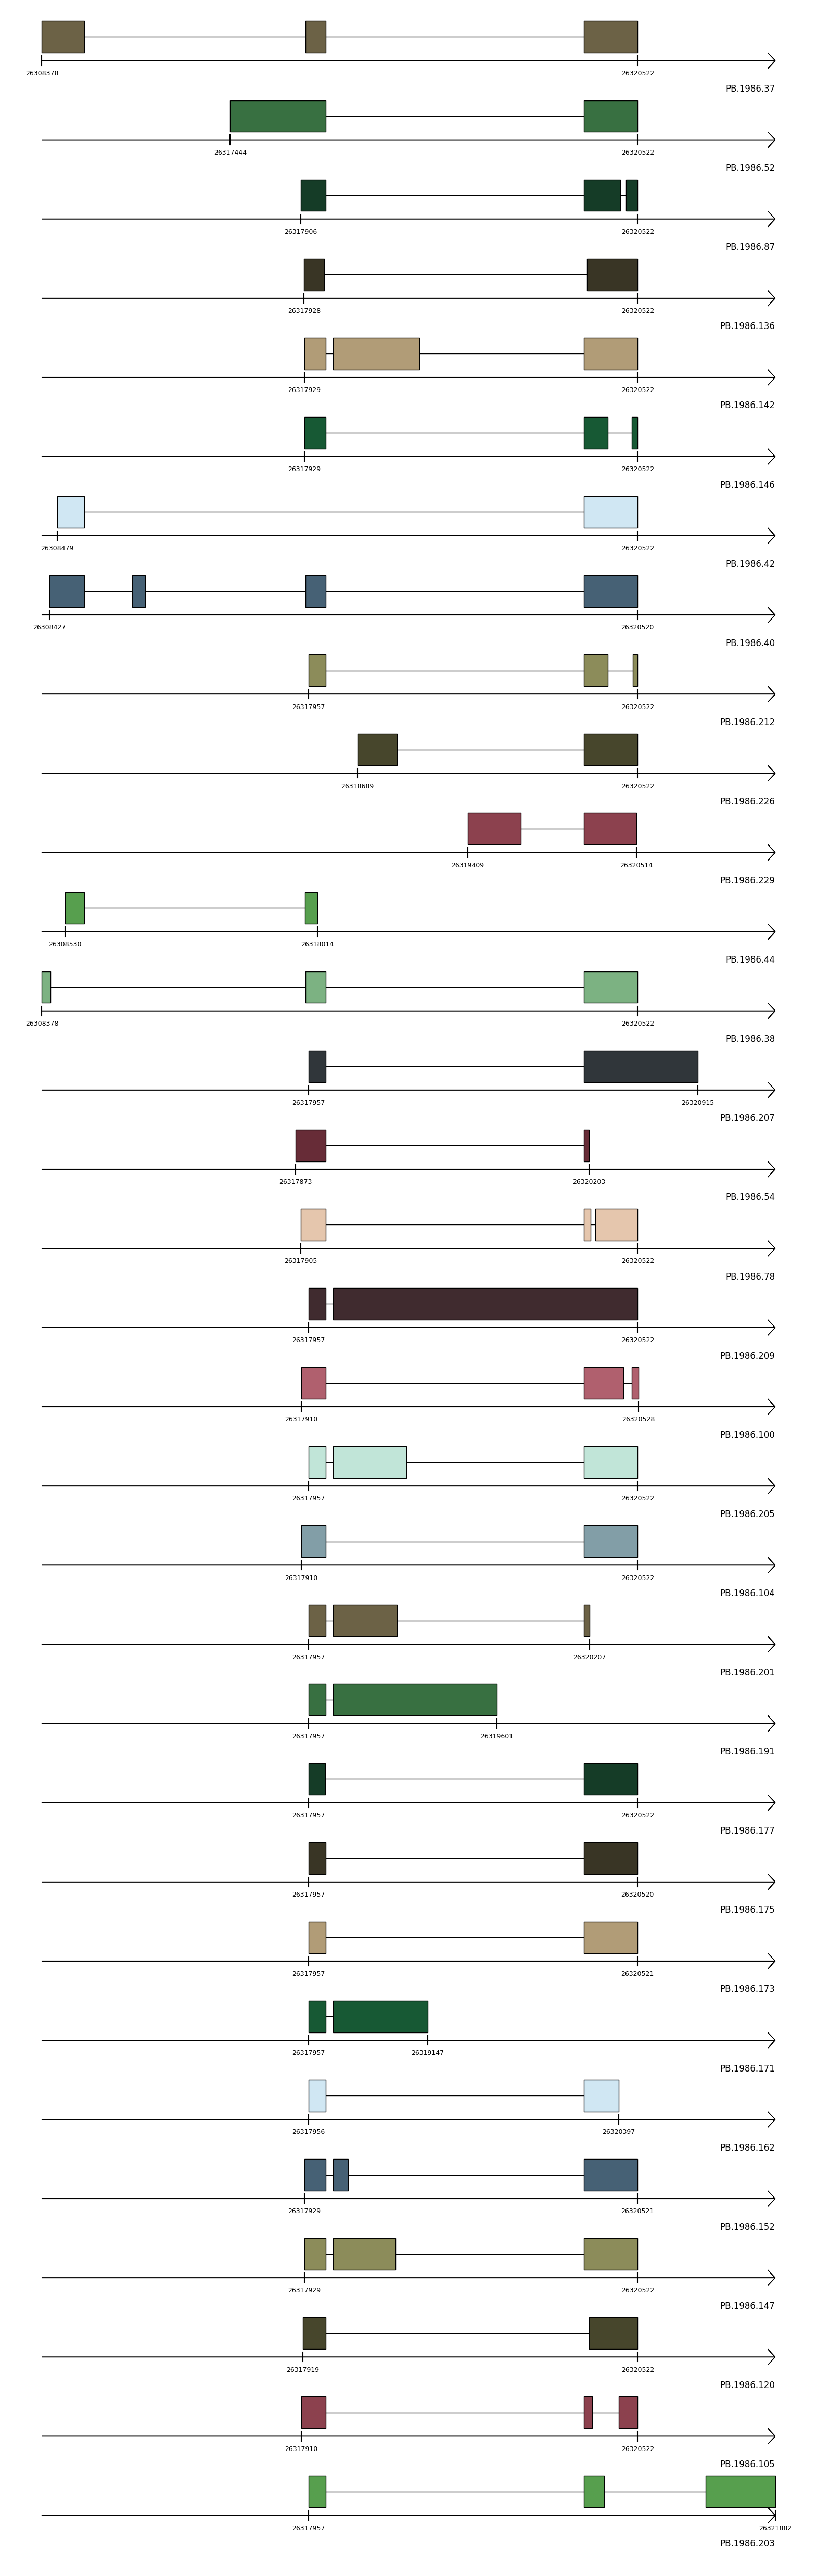

In [96]:
import pandas as pd
from allos.color_palette import ghibli, synthwave
import matplotlib.patches as mpatches
from allos.transcript_plots import TranscriptPlots
transcripts_colors = plot_combined_panel_on_condition(pairwise, dge_data=None, dge_short_data=None, gene_name='CD52', conditions_list=[], cell_types=[])
tp = TranscriptPlots(gtf_file="/data/analysis/data_diamant/allos_4/allos/nbs/scisoseq_transcripts.sorted.filtered_lite.gff")
transcripts_ids = []
colors_ids = []
for k, v in transcripts_colors.items():
    transcripts_ids.append(k)
    colors_ids.append(v)
tp.draw_transcripts_list(transcripts_ids, colors_ids)

In [3]:
from allos.readers_tests import *
import allos.preprocessing as pp
combined_mouse_data = process_mouse_data()
combined_mouse_data = pp.filter_transcripts_by_abundance(combined_mouse_data,  threshold_pct= 2)



🔎 Looking for file at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/e18.mouse.clusters.csv
✅ File found at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/e18.mouse.clusters.csv
✅ File already exists at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt.gz

🔄 Decompressing /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt.gz to /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt...
✅ Decompression complete.
Test data (mouse_1) downloaded successfully
✅ File already exists at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt.gz

🔄 Decompressing /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt.gz to /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt...
✅ Decom

         Falling back to preprocessing with `sc.pp.pca` and default params.


2025-05-17 22:00:29.404678: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-17 22:00:29.421934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747512029.439489 2819767 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747512029.444437 2819767 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-17 22:00:29.462625: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

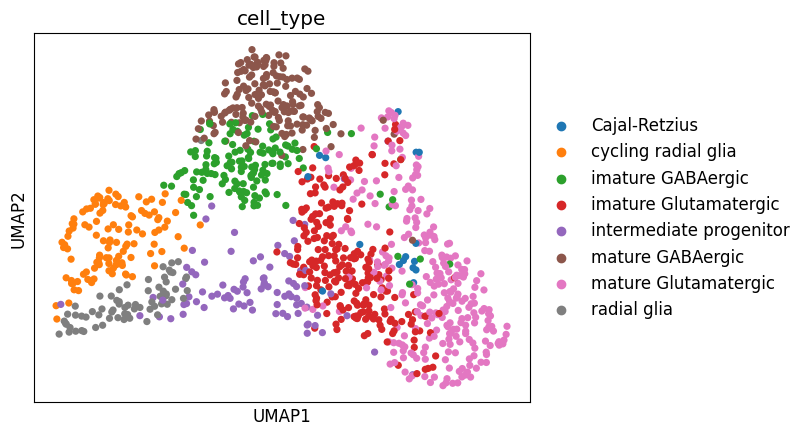

In [4]:
import allos.visuals as vs
sc.pp.normalize_total(combined_mouse_data, target_sum=1e6)
sc.pp.log1p(combined_mouse_data)
sc.pp.neighbors(combined_mouse_data)
sc.tl.umap(combined_mouse_data)
sc.pl.umap(combined_mouse_data, color = 'cell_type')

In [5]:
combined_mouse_data.var

,geneId
transcriptId,
ENSMUST00000156717.1,Klc2
ENSMUST00000212520.1,Capn15
ENSMUST00000025798.12,Klc2
ENSMUST00000231280.1,Eva1c
ENSMUST00000039286.4,Atg5
...,...
ENSMUST00000213971.1,Zfp445
ENSMUST00000047275.7,Bace2
ENSMUST00000019994.13,Popdc3


In [6]:
from allos.transcript_plots import TranscriptPlots
GTF_PATH = "/data/analysis/refdata-gex-GRCh38-2020-A/genes/genes.gtf"
tp = TranscriptPlots(gtf_file=str(GTF_PATH))

In [9]:
gr = GeneReports(combined_mouse_data)

In [ ]:
#gene_reports.write_gene_report("Clta")

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
import nbdev; nbdev.nbdev_export()